In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data = pd.read_csv('BankChurners.csv')

In [3]:
data.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='str')

<Axes: xlabel='Customer_Age', ylabel='Count'>

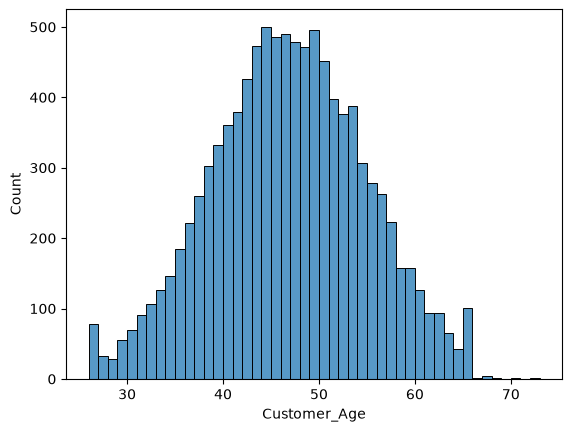

In [4]:
import seaborn as sns
sns.histplot(data['Customer_Age'])

<Axes: xlabel='count', ylabel='Education_Level'>

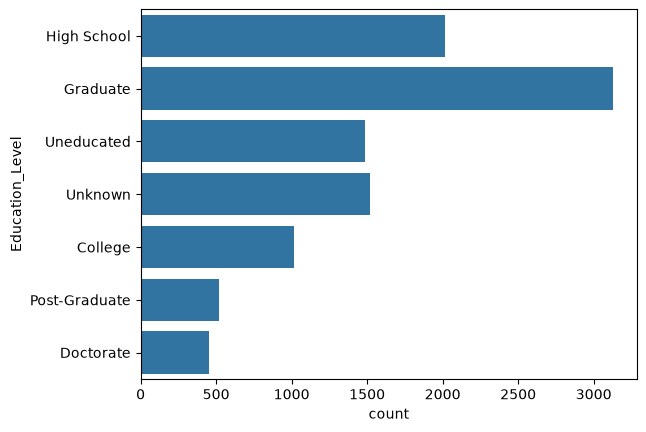

In [5]:
sns.countplot(data['Education_Level'])

<Axes: xlabel='count', ylabel='Attrition_Flag'>

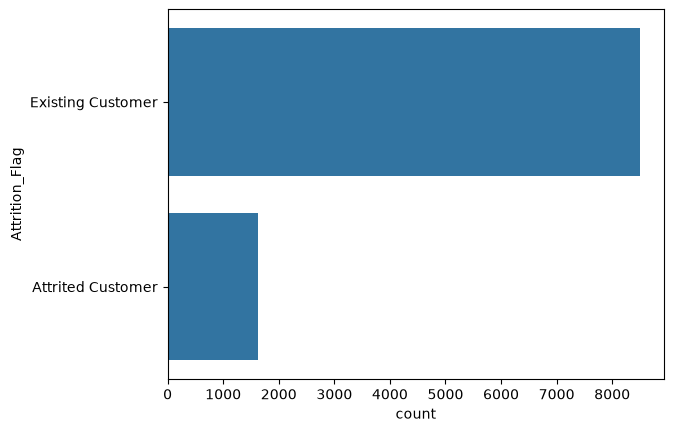

In [6]:
sns.countplot(data.Attrition_Flag)

<Axes: xlabel='Education_Level', ylabel='count'>

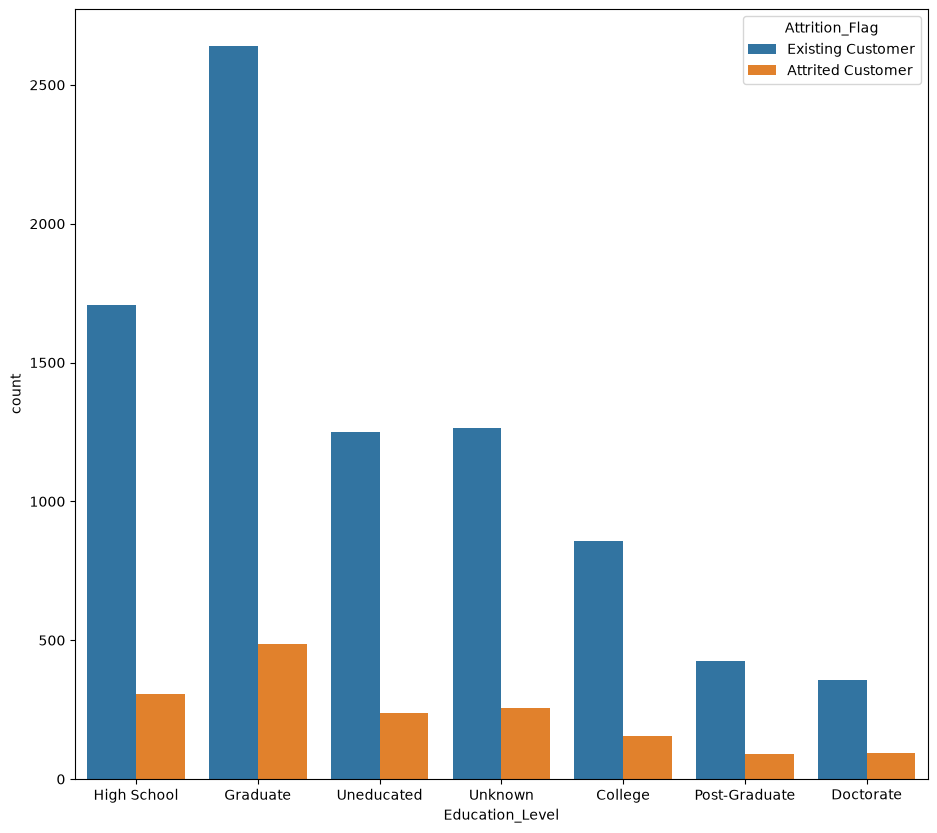

In [7]:
plt.figure(figsize=(11,10))
sns.countplot(data=data, x='Education_Level', hue='Attrition_Flag')


<Axes: xlabel='Marital_Status', ylabel='count'>

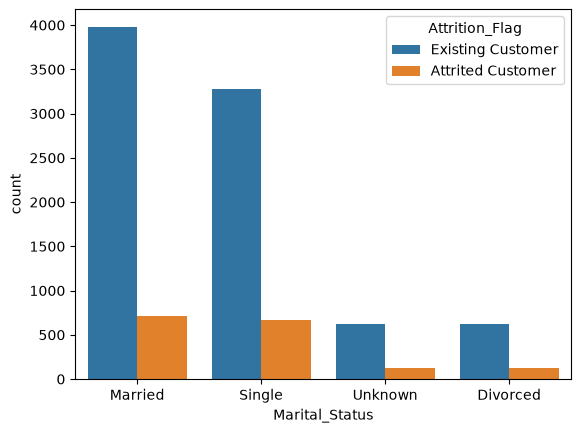

In [8]:
sns.countplot(data=data ,x='Marital_Status', hue= 'Attrition_Flag')

<Axes: xlabel='Gender', ylabel='count'>

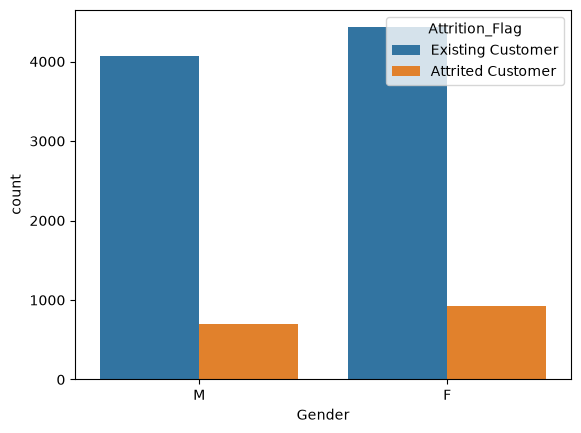

In [9]:
sns.countplot(data= data, x= 'Gender', hue='Attrition_Flag')

<Axes: xlabel='Education_Level', ylabel='Credit_Limit'>

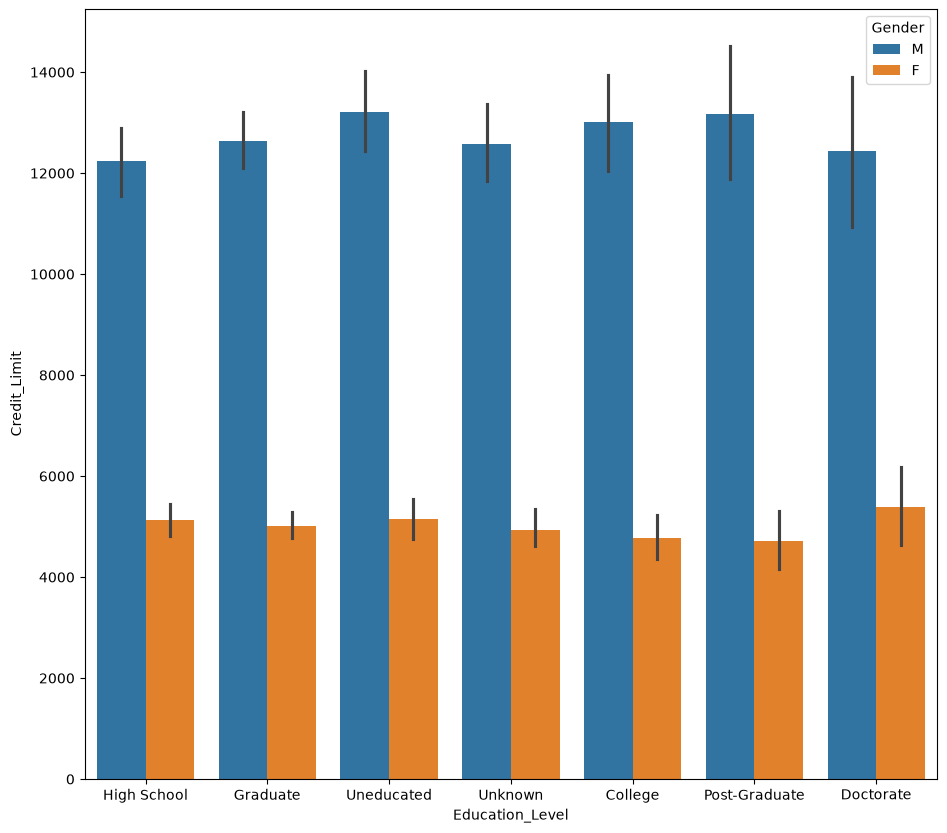

In [10]:
plt.figure(figsize=(11,10))
sns.barplot(data= data, x='Education_Level', y= 'Credit_Limit', hue= 'Gender')

In [11]:
data.Gender.value_counts()

Gender
F    5358
M    4769
Name: count, dtype: int64

<Axes: ylabel='Credit_Limit'>

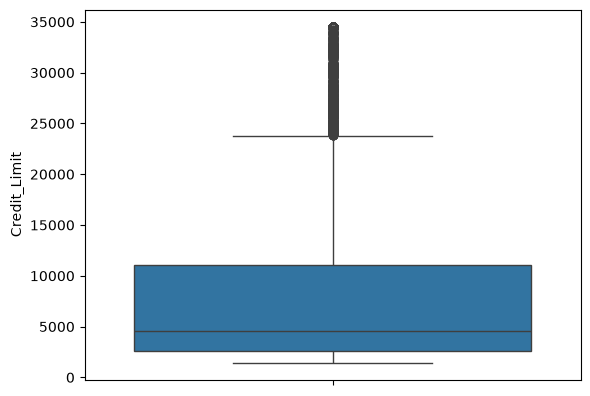

In [12]:
sns.boxplot(data['Credit_Limit'])

<Axes: ylabel='Customer_Age'>

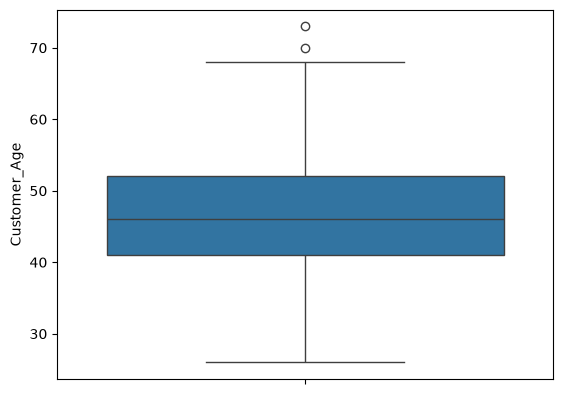

In [13]:
sns.boxplot(data['Customer_Age'])


<Axes: ylabel='Dependent_count'>

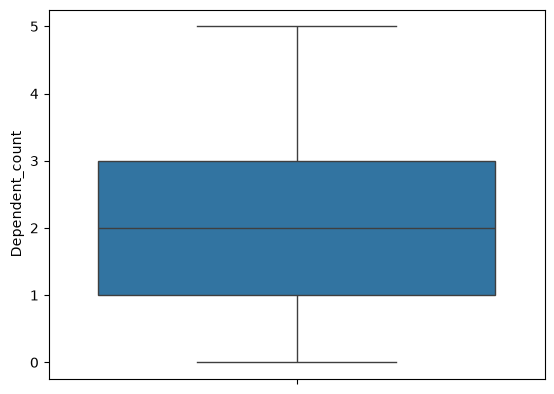

In [14]:
sns.boxplot(data['Dependent_count'])


<Axes: >

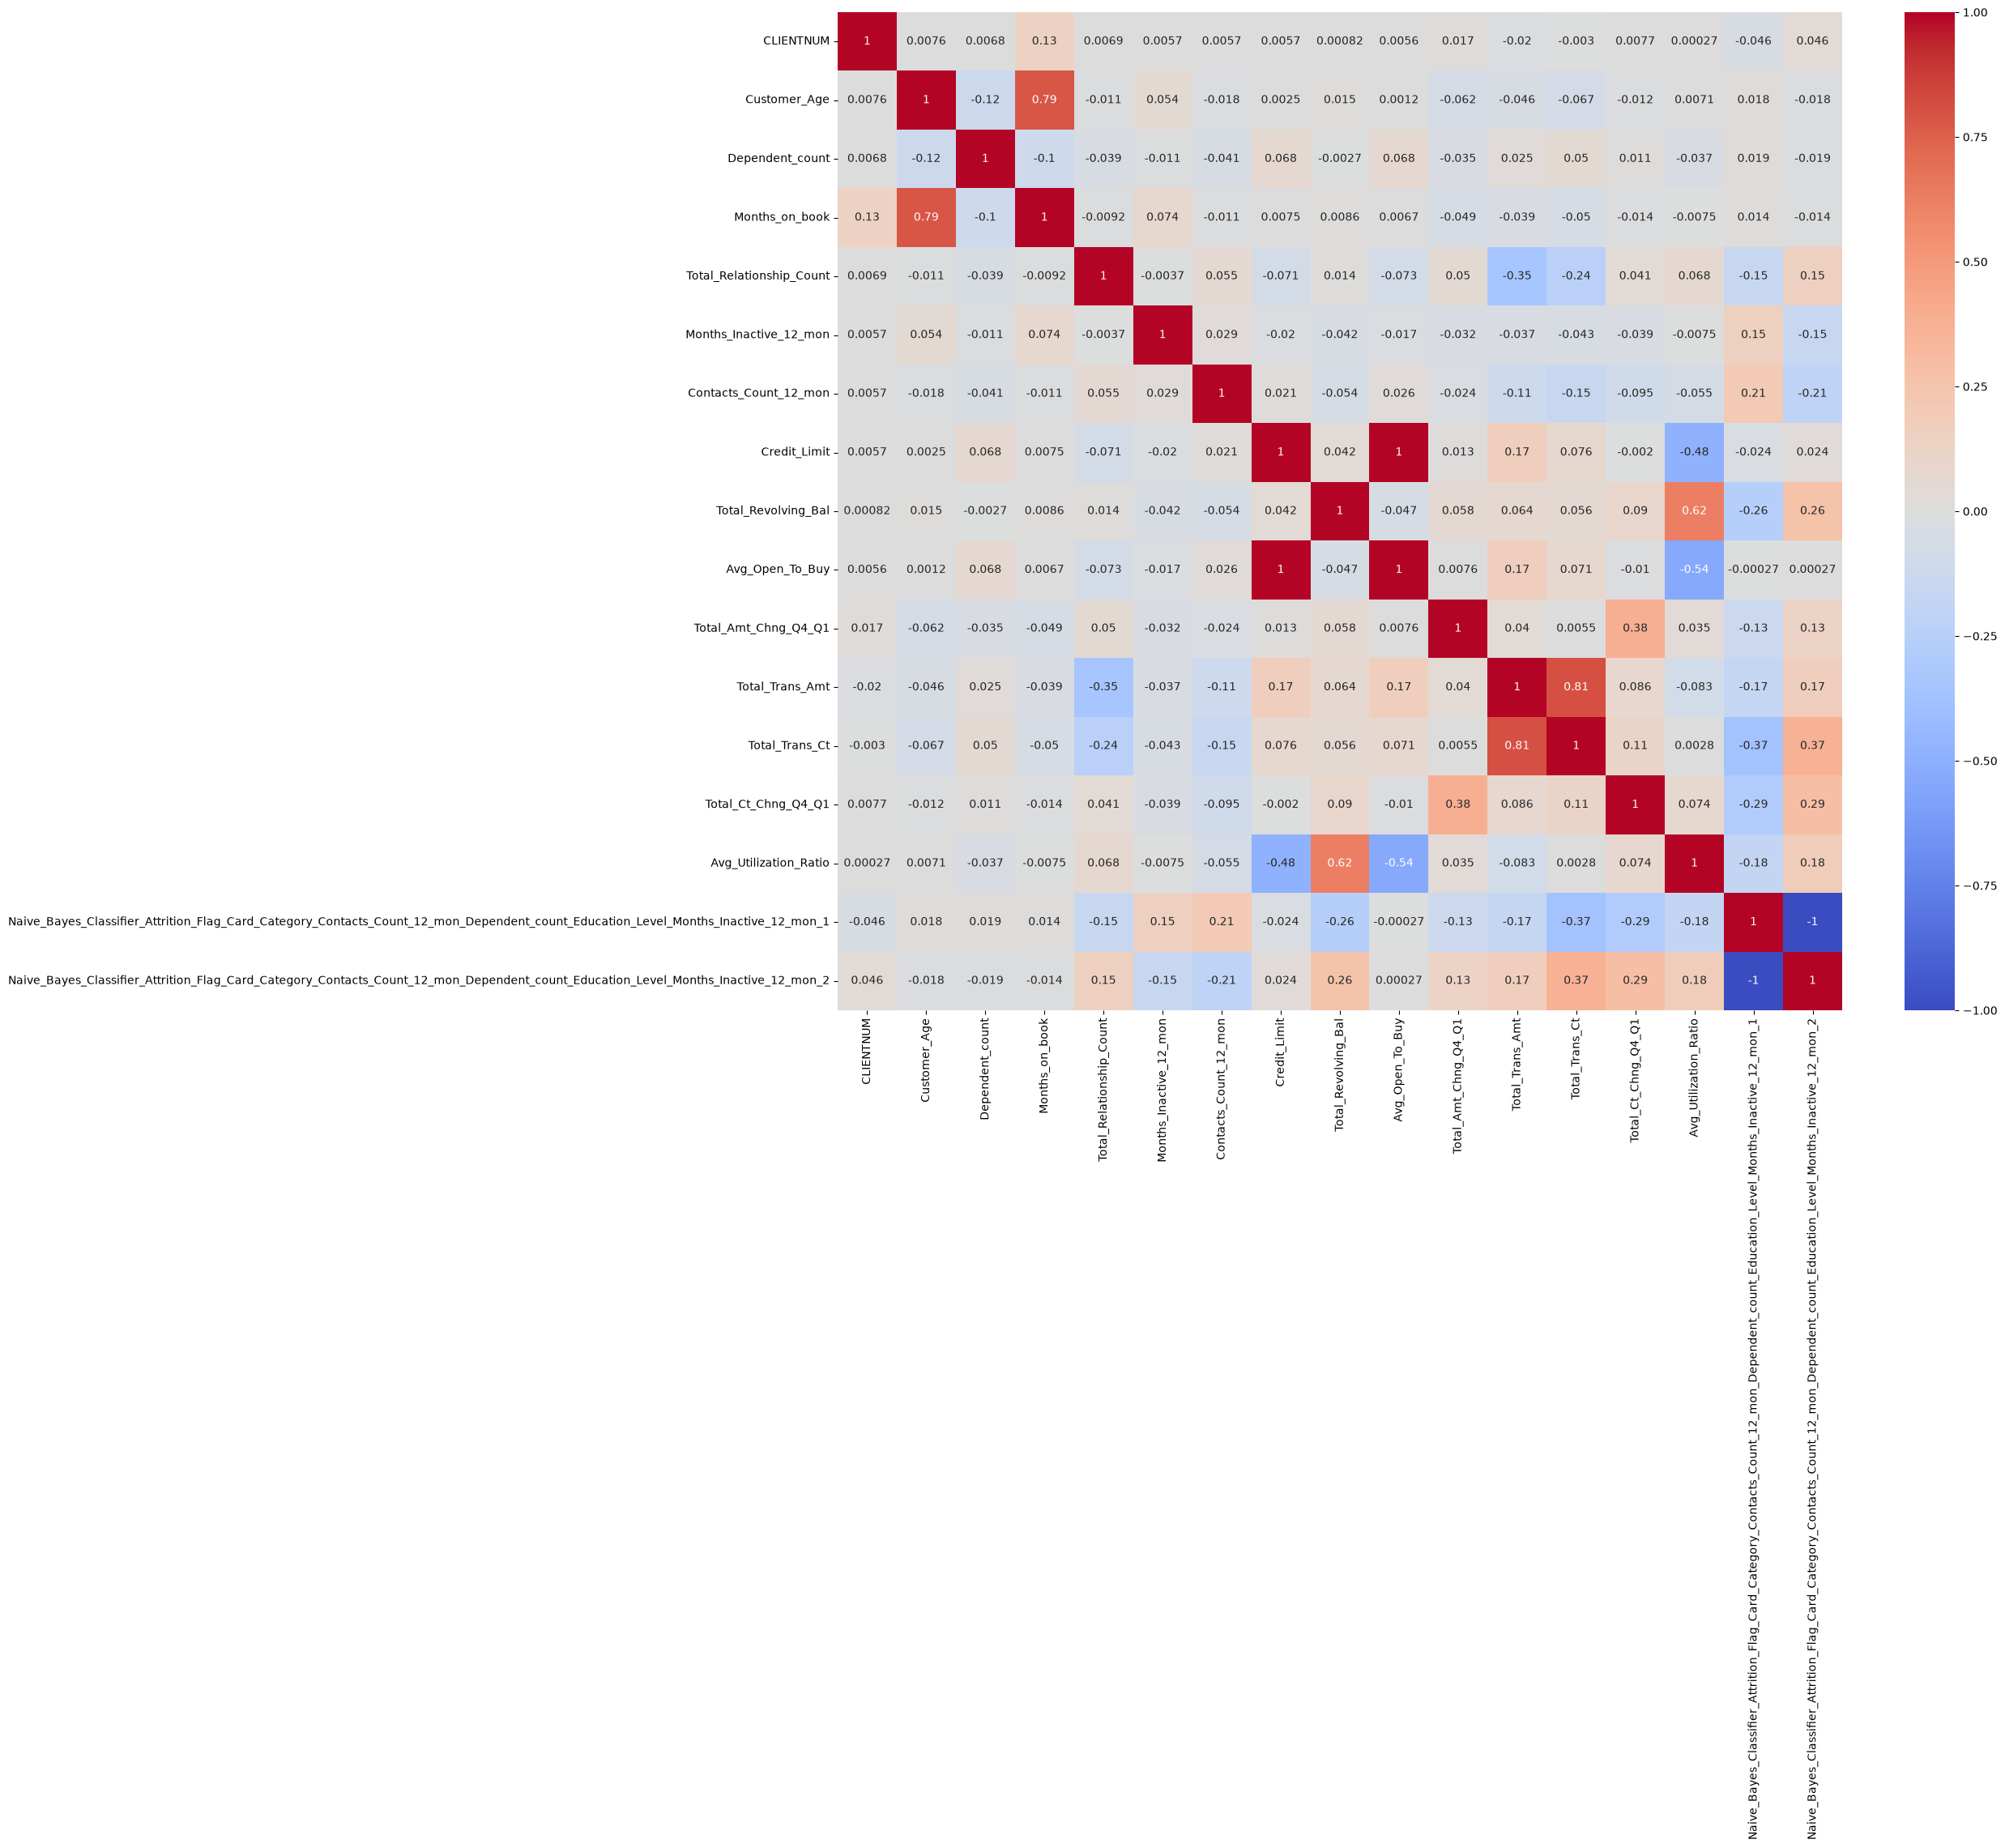

In [15]:
plt.figure(figsize=(20,16))
sns.heatmap(data.corr(method='pearson',numeric_only=True), annot= True, cmap= 'coolwarm')

### High Correlation
* `Total_Trans_Ct` vs `Total_Trans_Amount` -> **_0.81_**
* `Avg_Open_To_Buy` vs `Credit_Limit` -> **_1_**
* `Months_On_Book` vs `Customer_Age` -> **_0.79_**

In [16]:
cols = data.select_dtypes(include=np.number).columns.tolist()

In [17]:
def get_highly_correlated_features(new, threshold=0.8):
    """
    Find pairs of features with correlation higher than a given threshold.
    
    Parameters:
        new (pd.DataFrame): The dataset.
        threshold (float): Correlation threshold (absolute value).
        
    Returns:
        List of tuples: [(feature1, feature2, correlation), ...]
    """
    corr_matrix = new.corr().abs()  # absolute correlations
    high_corr_pairs = []

    # Iterate over upper triangle (to avoid duplicates & self-correlations)
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))
    
    return high_corr_pairs

get_highly_correlated_features(data[cols], threshold=0.7)

[('Customer_Age', 'Months_on_book', np.float64(0.7889123589930508)),
 ('Credit_Limit', 'Avg_Open_To_Buy', np.float64(0.995980543932001)),
 ('Total_Trans_Amt', 'Total_Trans_Ct', np.float64(0.8071920346514367)),
 ('Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
  'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2',
  np.float64(0.9999999999689079))]

In [18]:
data.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='str')

In [19]:
new = data.drop(columns=[
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2',
    'Total_Trans_Amt', 'Avg_Open_To_Buy', 'Months_on_book'
])

In [20]:
new.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,5,1,3,12691.0,777,1.335,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,6,1,2,8256.0,864,1.541,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,4,1,0,3418.0,0,2.594,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,3,4,1,3313.0,2517,1.405,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,5,1,0,4716.0,0,2.175,28,2.500,0.000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


target = "Attrition_Flag"

categorical_ohe = ["Gender", "Education_Level", "Marital_Status", "Card_Category"]
categorical_ordinal = ["Income_Category"]
numeric_features = [
    "Customer_Age", "Dependent_count", "Total_Relationship_Count",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Credit_Limit",
    "Total_Revolving_Bal", "Total_Amt_Chng_Q4_Q1", "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio"
]


ohe_encoder = OneHotEncoder(handle_unknown="ignore")

income_order = [["Less than $40K", "$40K - $60K", "$60K - $80K",
                 "$80K - $120K", "$120K +", "Unknown"]]
ordinal_encoder = OrdinalEncoder(categories=income_order)

preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", ohe_encoder, categorical_ohe),
        ("ordinal", ordinal_encoder, categorical_ordinal),
        ("scaler", StandardScaler(), numeric_features)
    ]
)


pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42))
])


param_grid = {
    "classifier__n_estimators": [100, 200, 500],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",   
    cv=5,
    n_jobs=-1,
    verbose=2
)


X = new.drop(columns=[target])
y = new[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)
print("Test ROC-AUC:", grid_search.score(X_test, y_test))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}
Best CV ROC-AUC: 0.9585188361592654
Test ROC-AUC: 0.9641278885723329


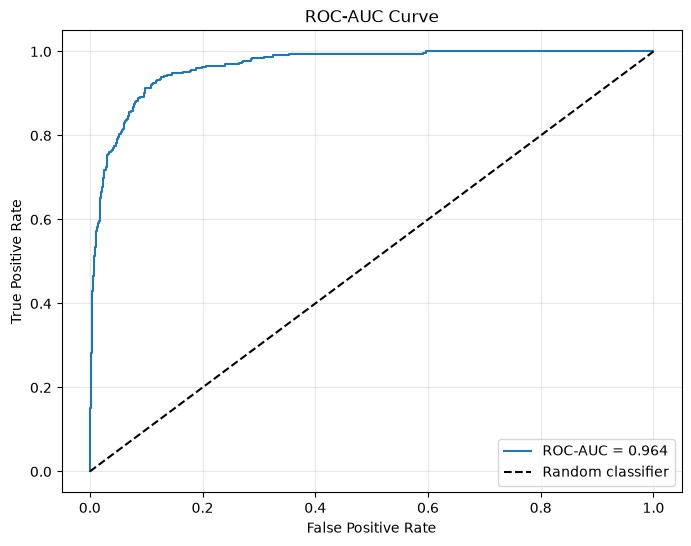

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

positive_label = "Attrited Customer"
positive_index = list(grid_search.classes_).index(positive_label)

y_score = grid_search.predict_proba(X_test)[:, positive_index]
y_true = (y_test == positive_label).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_score)
auc_score = roc_auc_score(y_true, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_17680\684989677.py:55: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, plot_type="bar")


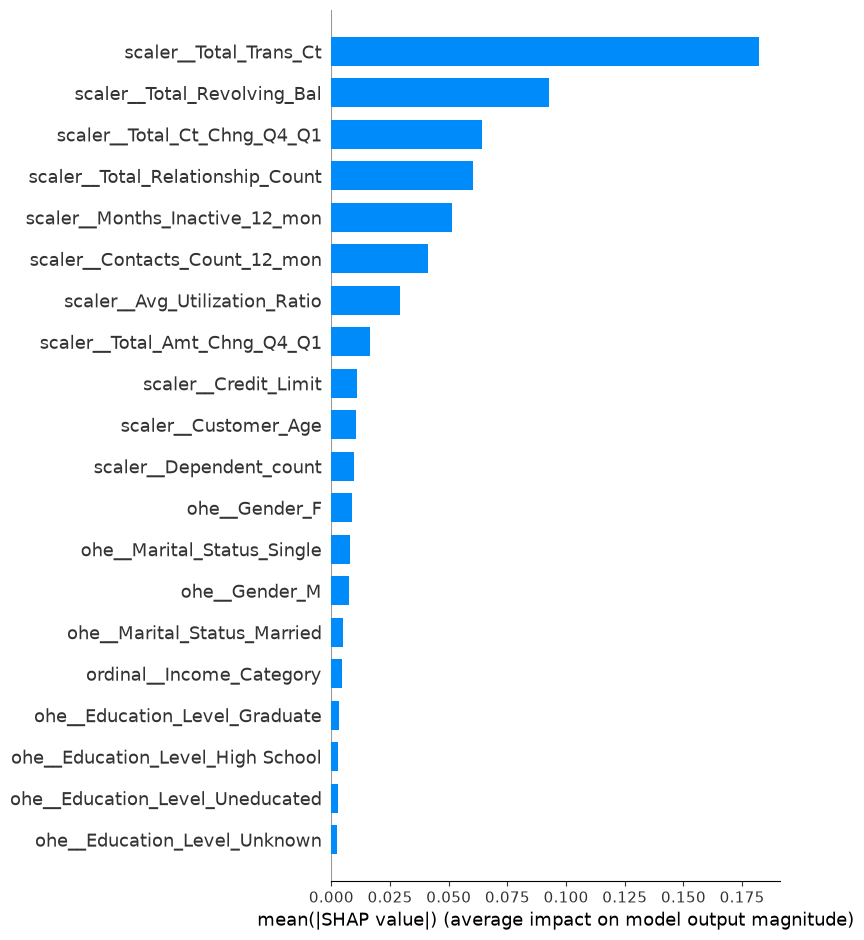

C:\Users\DELL\AppData\Local\Temp\ipykernel_17680\684989677.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain)


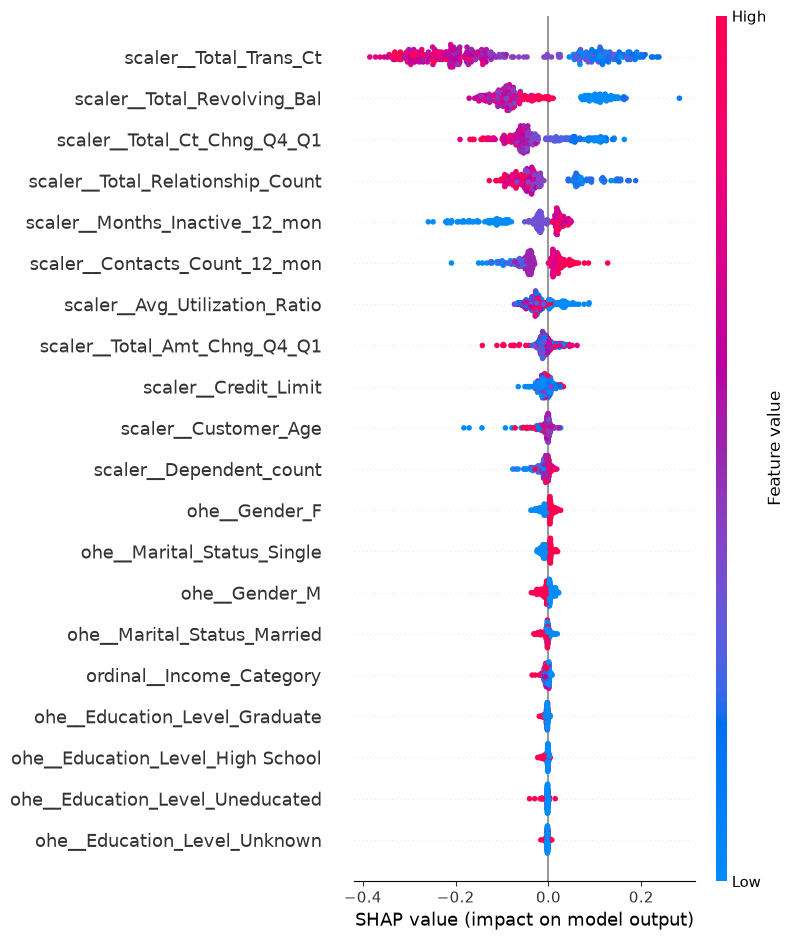

In [ ]:
import shap

positive_index = list(grid_search.classes_).index(positive_label)

def predict_positive(X):
    return grid_search.predict_proba(X)[:, positive_index]

background = X_test.sample(min(200, len(X_test)), random_state=42)
X_explain = X_test.sample(min(300, len(X_test)), random_state=42)

explainer = shap.Explainer(predict_positive, background)

fitted_pipeline = grid_search.best_estimator_
fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
fitted_classifier = fitted_pipeline.named_steps["classifier"]

X_explain_transformed = fitted_preprocessor.transform(X_explain)
feature_names = fitted_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(fitted_classifier)
raw_shap_values = explainer(
    X_explain_transformed,
    check_additivity=False
)

if isinstance(raw_shap_values, list):
    values = raw_shap_values[positive_index]
    base_value = explainer.expected_value[positive_index]
else:
    values = raw_shap_values.values
    base_value = raw_shap_values.base_values

    if values.ndim == 3:
        values = values[:, :, positive_index]
        if np.ndim(base_value) > 1:
            base_value = base_value[:, positive_index]

shap_values = shap.Explanation(
    values=values,
    base_values=base_value,
    data=X_explain_transformed.toarray()
    if hasattr(X_explain_transformed, "toarray")
    else X_explain_transformed,
    feature_names=feature_names
)

X_explain = pd.DataFrame(
    shap_values.data,
    columns=feature_names,
    index=X_explain.index
)

shap.summary_plot(shap_values, X_explain, plot_type="bar")
shap.summary_plot(shap_values, X_explain)

**SHAP plots explanation**

These plots explain how the Random Forest predicts whether a customer will churn.

### 1. SHAP summary/beeswarm plot

- Each row represents a feature.
- Features are ordered by importance, from top to bottom.
- Each dot represents one customer.
- The horizontal position shows the feature’s impact:
  - Right of zero: increases the predicted probability of churn.
  - Left of zero: decreases the predicted probability of churn.
- Color represents the original feature value:
  - Red: high value.
  - Blue: low value.

For example:

- `scaler__Total_Trans_Ct` is the most influential feature.
  - High values, shown in red, are mostly on the left, meaning frequent transactions generally reduce churn risk.
  - Low values, shown in blue, are mostly on the right, meaning fewer transactions increase churn risk.
- High `Total_Revolving_Bal` values tend to reduce churn risk, while low values tend to increase it.
- High `Months_Inactive_12_mon` values tend to increase churn risk.
- High `Contacts_Count_12_mon` values also tend to increase churn risk.
- Features near the bottom, such as education and marital-status variables, have relatively small effects on the model output.

The SHAP value is measured on the model’s output scale. Larger absolute values indicate stronger influence.

### 2. SHAP bar plot

This plot shows the average absolute SHAP value for each feature:

```python
mean(|SHAP value|)
```

It measures overall feature importance without considering whether the feature increases or decreases churn.

The model considers these features most important:

1. `Total_Trans_Ct`
2. `Total_Revolving_Bal`
3. `Total_Ct_Chng_Q4_Q1`
4. `Total_Relationship_Count`
5. `Months_Inactive_12_mon`
6. `Contacts_Count_12_mon`

For example, `Total_Trans_Ct` has the longest bar, so it has the greatest average influence on predictions. However, this plot does not show the direction of the influence; the beeswarm plot provides that information.

### 3. Explanation of the code

The code first transforms the original categorical and numeric data:

```python
X_explain_transformed = fitted_preprocessor.transform(X_explain)
```

This is necessary because the Random Forest receives encoded numeric data rather than raw text values.

The preprocessor creates feature names such as:

```text
scaler__Total_Trans_Ct
ohе__Gender_F
ordinal__Income_Category
```

The model is then explained using:

```python
explainer = shap.TreeExplainer(fitted_classifier)
```

SHAP calculates how much each feature contributes to each prediction. The code selects the `"Attrited Customer"` class using `positive_index`, so the plots describe factors influencing churn predictions.

Finally:

```python
shap.summary_plot(shap_values, X_explain, plot_type="bar")
shap.summary_plot(shap_values, X_explain)
```

creates the global importance bar chart and the detailed beeswarm plot.

One important interpretation: SHAP shows relationships learned by the model, not proof that a feature causes churn.